In [ ]:
import torch
from PIL import Image
import open_clip
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import numpy as np

model, _, preprocess = open_clip.create_model_and_transforms('TULIP-so400m-14-384', pretrained='./tulip-so400m-14-384.ckpt')
model.eval()

gemma_tokenizer = AutoTokenizer.from_pretrained("ZinengTang/tulip-tokenizer")

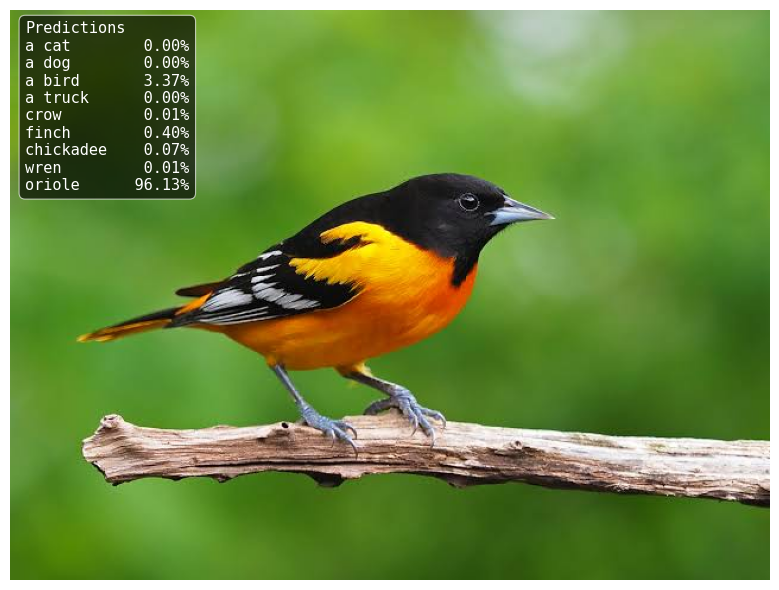

In [6]:
image_path = "sample.jpg"
labels = ["a cat", "a dog", "a bird", "a truck", "crow", "finch", "chickadee", "wren", "oriole"]
image = preprocess(Image.open(image_path)).unsqueeze(0)
text = gemma_tokenizer(
    labels,
    return_tensors="pt",
    max_length=64,
    padding="max_length",
    truncation=True,
).input_ids

with torch.no_grad(), torch.autocast("cuda"):
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)

    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    similarities = (100.0 * image_features @ text_features.T).softmax(dim=-1)

img = Image.open(image_path)
probs = similarities.cpu().numpy().flatten()

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
label_width = max(len(label) for label in labels)
prob_text = "\n".join(
    f"{label:<{label_width}}  {prob:>7.2%}" for label, prob in zip(labels, probs)
)
ax = plt.gca()
ax.text(
    0.02,
    0.98,
    "Predictions\n" + prob_text,
    transform=ax.transAxes,
    fontsize=11,
    family="monospace",
    verticalalignment="top",
    color="white",
    bbox=dict(
        facecolor="black",
        alpha=0.65,
        edgecolor="white",
        linewidth=0.8,
        boxstyle="round,pad=0.4",
    ),
)

plt.tight_layout()
plt.show()